## 1. Libraries

In [19]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import itertools
import time
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')

## 2. Input Data

In [3]:
# Import Data
df = pd.read_csv("data.csv")

df.head()

,iso3,year,gdp_per_capita,energy_use_pc,urbanization_pct,industry_pct_gdp,trade_pct_gdp,fossil_fuel_pct,natres_pct_gdp,fdi_pct_gdp,eps,ecological_footprint
0,AUT,2000,38571.08588,3570.948532,66.769024,28.611552,85.842608,68.732310,0.154666,4.333237,1.888889,5.80
1,AUT,2001,38929.75380,3758.793163,66.840816,28.439892,87.996257,70.588580,0.159532,2.895722,1.888889,6.17
2,AUT,2002,39313.72251,3771.719492,66.888746,27.668343,87.584494,71.076910,0.158690,0.065001,1.888889,5.63
3,AUT,2003,39569.28856,3956.938946,66.926357,27.697936,86.882226,75.879486,0.151823,2.375576,2.194444,5.84
4,AUT,2004,40333.33072,3974.506368,66.955861,27.614789,91.474220,73.880830,0.131901,1.064017,2.194444,5.98


## 3. Condition Window

We want to predict EF, how? We give the model w years of data and we say predict the EF of year w+1. 
So we have to define a function for creating windows/conditions. 

Forexample with w=3, we have features for 3 years and also EF of next year. Example: a window might have features of 2000,2001,2002 and target of 2003.

In [4]:
# First we determine the fearures and target
FEATURE_COLS = [
    "gdp_per_capita", "energy_use_pc", "urbanization_pct",
    "industry_pct_gdp", "trade_pct_gdp", "fossil_fuel_pct",
    "natres_pct_gdp", "fdi_pct_gdp", "eps",
]

TARGET_COL = "ecological_footprint"

#**********************************************************************************

def make_windows(df, w, years_for_target, feature_cols=FEATURE_COLS,
                  target_col=TARGET_COL):
    """
    Build (X, y) windows for one split.
 
    df               : our data
    w                : window/condition length (number of past years used as input)
    years_for_target : iterable of years the PREDICTED value (t+1) must
                        fall in, for a window to belong to this split
 
    Returns:
        X    : array (n_samples, w, n_features)
        y    : array (n_samples,)
        meta : list of (iso3, target_year) for traceability
    """
    # Convert years_for_target to set
    years_for_target = set(years_for_target)

    # We sort our data (rows) first based on country and then by year. 
    df = df.sort_values(["iso3", "year"])
 
    # Three empty lists that will accumulate results as we loop. X_list will hold one array per window (each a w × n_features block), y_list holds the single target value per window, meta holds (country, year) so you can always trace a prediction back to what it actually represents.
    X_list, y_list, meta = [], [], []
    
    # df.groupby("iso3") splits the dataframe into one chunk per country. Looping over it gives you country (e.g. "DEU") and g, the sub-dataframe containing only that country's rows.
    for country, g in df.groupby("iso3"):

        # Re-indexes that country's rows by year instead of the default 0,1,2,... row numbers. This lets us do g.loc[2015] to grab that country's row for 2015 directly, instead of filtering (g[g["year"]==2015]) every time — much faster and cleaner.
        g = g.set_index("year")
        # The set of years this country actually has data for (here, always 2000–2020 since your cleaned data is a balanced panel — but the code doesn't assume that, it's defensive).
        available_years = set(g.index)
 
        for target_year in years_for_target:
            t = target_year - 1                      # last input year
            window_years = list(range(t - w + 1, t + 1))  # w years: t-w+1..t
 
            # skip if any required input year or the target year is missing
            if not all(y in available_years for y in window_years):
                continue
            if target_year not in available_years:
                continue
 
            X_window = g.loc[window_years, feature_cols].values  # (w, n_features)
            y_target = g.loc[target_year, target_col]
 
            X_list.append(X_window)
            y_list.append(y_target)
            meta.append((country, target_year))
 
    if not X_list:
        return (np.empty((0, w, len(feature_cols))),
                np.empty((0,)), [])
 
    return np.array(X_list), np.array(y_list), meta
 

In [11]:
def build_dataset(df, w, train_years, val_years, test_years,
                   feature_cols=FEATURE_COLS, target_col=TARGET_COL):
    scaler = StandardScaler()
    train_rows = df[df["year"].isin(train_years)]
    scaler.fit(train_rows[feature_cols].values)

    df_scaled = df.copy()
    df_scaled[feature_cols] = scaler.transform(df[feature_cols].values)

    X_train, y_train, meta_train = make_windows(df_scaled, w, train_years, feature_cols, target_col)
    X_val,   y_val,   meta_val   = make_windows(df_scaled, w, val_years,   feature_cols, target_col)
    X_test,  y_test,  meta_test  = make_windows(df_scaled, w, test_years,  feature_cols, target_col)

    return {
        "X_train": X_train, "y_train": y_train, "meta_train": meta_train,
        "X_val":   X_val,   "y_val":   y_val,   "meta_val":   meta_val,
        "X_test":  X_test,  "y_test":  y_test,  "meta_test":  meta_test,
        "scaler":  scaler, "w": w,
    }


## 4. Model

In [5]:
class EFLSTM(nn.Module):
    def __init__(self, n_features=9, hidden_size=16):
        super().__init__()
 
        self.lstm = nn.LSTM(
            input_size=n_features,   # how many features per timestep (9)
            hidden_size=hidden_size, # size of the LSTM's internal memory (16)
            num_layers=1,            # single LSTM layer
            batch_first=True,        # input shape = (batch, timesteps, features)
        )
 
        self.output_layer = nn.Linear(hidden_size, 1)  # 16 numbers -> 1 prediction
 
    def forward(self, x):
        """
        x: tensor of shape (batch_size, w, n_features)
        returns: tensor of shape (batch_size,) - predicted EF
        """
        lstm_out, (h_n, c_n) = self.lstm(x)
        # lstm_out: (batch, w, hidden_size) - output at EVERY timestep
        # h_n:      (1, batch, hidden_size) - final hidden state (last timestep)
 
        last_step = lstm_out[:, -1, :]      # take only the last timestep's output
        # equivalent to h_n.squeeze(0), same values
 
        prediction = self.output_layer(last_step)  # (batch, 1)
        return prediction.squeeze(-1)               # (batch,)
 
 

 

In [6]:
if __name__ == "__main__":
    # quick sanity check with fake data shaped like your real windows
    model = EFLSTM(n_features=9, hidden_size=16)
 
    batch_size, w = 4, 5
    fake_x = torch.randn(batch_size, w, 9)
 
    pred = model(fake_x)
    print("Input shape: ", fake_x.shape)
    print("Output shape:", pred.shape)
    print("Predictions: ", pred)
 
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Total trainable parameters: {n_params}")

Input shape:  torch.Size([4, 5, 9])
Output shape: torch.Size([4])
Predictions:  tensor([ 0.0401,  0.0845,  0.0151, -0.0116], grad_fn=<SqueezeBackward1>)
Total trainable parameters: 1745


## 5. Train Loop

In [7]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [9]:
W = 5
TRAIN_YEARS = list(range(2001, 2016))
VAL_YEARS   = list(range(2016, 2019))
TEST_YEARS  = list(range(2019, 2021))

HIDDEN_SIZE = 16
BATCH_SIZE = 16
LEARNING_RATE = 1e-3
MAX_EPOCHS = 300
PATIENCE = 20

In [14]:
data = build_dataset(df, W, TRAIN_YEARS, VAL_YEARS, TEST_YEARS)

print(f"Window size w={W}")
print("Train samples:", data["X_train"].shape[0])
print("Val samples:  ", data["X_val"].shape[0])
print("Test samples: ", data["X_test"].shape[0])

def make_loader(X, y, batch_size, shuffle):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    return DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(data["X_train"], data["y_train"], BATCH_SIZE, shuffle=True)
val_loader   = make_loader(data["X_val"],   data["y_val"],   BATCH_SIZE, shuffle=False)


Window size w=5
Train samples: 341
Val samples:   93
Test samples:  62


In [15]:
n_features = data["X_train"].shape[2]
model = EFLSTM(n_features=n_features, hidden_size=HIDDEN_SIZE)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss, n_samples = 0.0, 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = loss_fn(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
        n_samples += X_batch.size(0)
    return total_loss / n_samples


In [16]:
def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss, n_samples = 0.0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            preds = model(X_batch)
            loss = loss_fn(preds, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            n_samples += X_batch.size(0)
    return total_loss / n_samples

In [17]:
best_val_loss = float("inf")
epochs_without_improvement = 0
best_state = None
history = {"epoch": [], "train_loss": [], "val_loss": []}

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn)
    val_loss = evaluate(model, val_loader, loss_fn)

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d} | train MSE: {train_loss:.4f} | val MSE: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch}. Best val MSE: {best_val_loss:.4f}")
        break

model.load_state_dict(best_state)

Epoch    1 | train MSE: 27.3912 | val MSE: 23.3387
Epoch   10 | train MSE: 2.2767 | val MSE: 1.4630
Epoch   20 | train MSE: 1.0091 | val MSE: 0.8787
Epoch   30 | train MSE: 0.6885 | val MSE: 0.7330
Epoch   40 | train MSE: 0.4998 | val MSE: 0.6880
Epoch   50 | train MSE: 0.2952 | val MSE: 0.5279
Epoch   60 | train MSE: 0.1974 | val MSE: 0.4663
Epoch   70 | train MSE: 0.1573 | val MSE: 0.4421
Epoch   80 | train MSE: 0.1360 | val MSE: 0.4086
Epoch   90 | train MSE: 0.1248 | val MSE: 0.3977
Epoch  100 | train MSE: 0.1178 | val MSE: 0.3941
Epoch  110 | train MSE: 0.1069 | val MSE: 0.3513
Epoch  120 | train MSE: 0.1058 | val MSE: 0.3725
Epoch  130 | train MSE: 0.0962 | val MSE: 0.3532
Epoch  140 | train MSE: 0.0949 | val MSE: 0.3386
Epoch  150 | train MSE: 0.0859 | val MSE: 0.3476
Epoch  160 | train MSE: 0.0807 | val MSE: 0.3277
Epoch  170 | train MSE: 0.0831 | val MSE: 0.3510
Early stopping at epoch 176. Best val MSE: 0.3180


<All keys matched successfully>

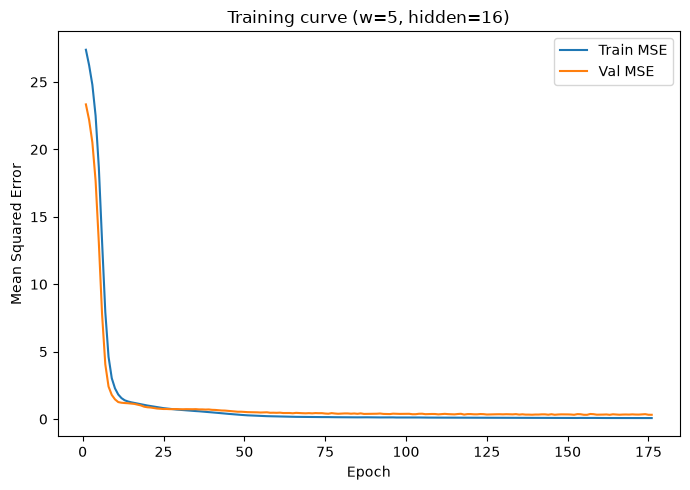

Best val MSE: 0.3180


In [18]:
plt.figure(figsize=(7, 5))
plt.plot(history["epoch"], history["train_loss"], label="Train MSE")
plt.plot(history["epoch"], history["val_loss"], label="Val MSE")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title(f"Training curve (w={W}, hidden={HIDDEN_SIZE})")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best val MSE: {best_val_loss:.4f}")

## 5. Evaluation

In [20]:
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(data["X_test"], dtype=torch.float32)
    y_pred_test = model(X_test_tensor).numpy()

y_true_test = data["y_test"]
meta_test = data["meta_test"]  # list of (iso3, target_year), same order as y_pred/y_true


In [21]:
mae = mean_absolute_error(y_true_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
r2 = r2_score(y_true_test, y_pred_test)

print(f"Test MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R2:   {r2:.4f}")

Test MAE:  0.6445
Test RMSE: 0.8582
Test R2:   0.7131


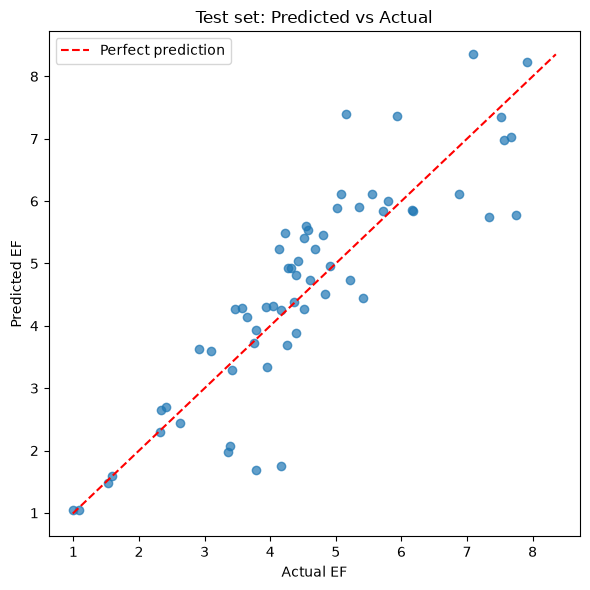

In [22]:
plt.figure(figsize=(6, 6))
plt.scatter(y_true_test, y_pred_test, alpha=0.7)
lims = [min(y_true_test.min(), y_pred_test.min()), max(y_true_test.max(), y_pred_test.max())]
plt.plot(lims, lims, 'r--', label="Perfect prediction")
plt.xlabel("Actual EF")
plt.ylabel("Predicted EF")
plt.title("Test set: Predicted vs Actual")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
results_df = pd.DataFrame(meta_test, columns=["iso3", "year"])
results_df["actual"] = y_true_test
results_df["predicted"] = y_pred_test
results_df["abs_error"] = np.abs(results_df["actual"] - results_df["predicted"])

per_country = results_df.groupby("iso3")["abs_error"].mean().sort_values(ascending=False)
print("\nMean absolute error by country (worst to best):")
print(per_country)


Mean absolute error by country (worst to best):
iso3
CHL    2.252446
BEL    1.833913
DNK    1.784968
CHN    1.338987
DEU    1.111960
RUS    0.848378
KOR    0.799087
CAN    0.793147
CHE    0.758723
ESP    0.752420
POL    0.750981
SVN    0.648363
EST    0.614570
ZAF    0.605941
ISR    0.579285
CZE    0.497144
USA    0.466860
SWE    0.424942
GRC    0.363599
FRA    0.353168
PRT    0.318192
GBR    0.304252
BRA    0.301799
ITA    0.297723
NOR    0.297528
AUT    0.271049
SVK    0.265339
JPN    0.187883
MEX    0.094732
IND    0.041225
IDN    0.022272
Name: abs_error, dtype: float64


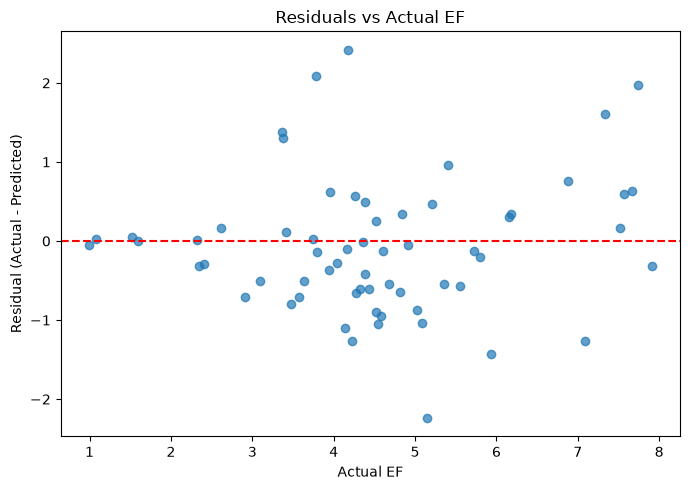

In [24]:
plt.figure(figsize=(7, 5))
residuals = results_df["actual"] - results_df["predicted"]
plt.scatter(results_df["actual"], residuals, alpha=0.7)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Actual EF")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Actual EF")
plt.tight_layout()
plt.show()

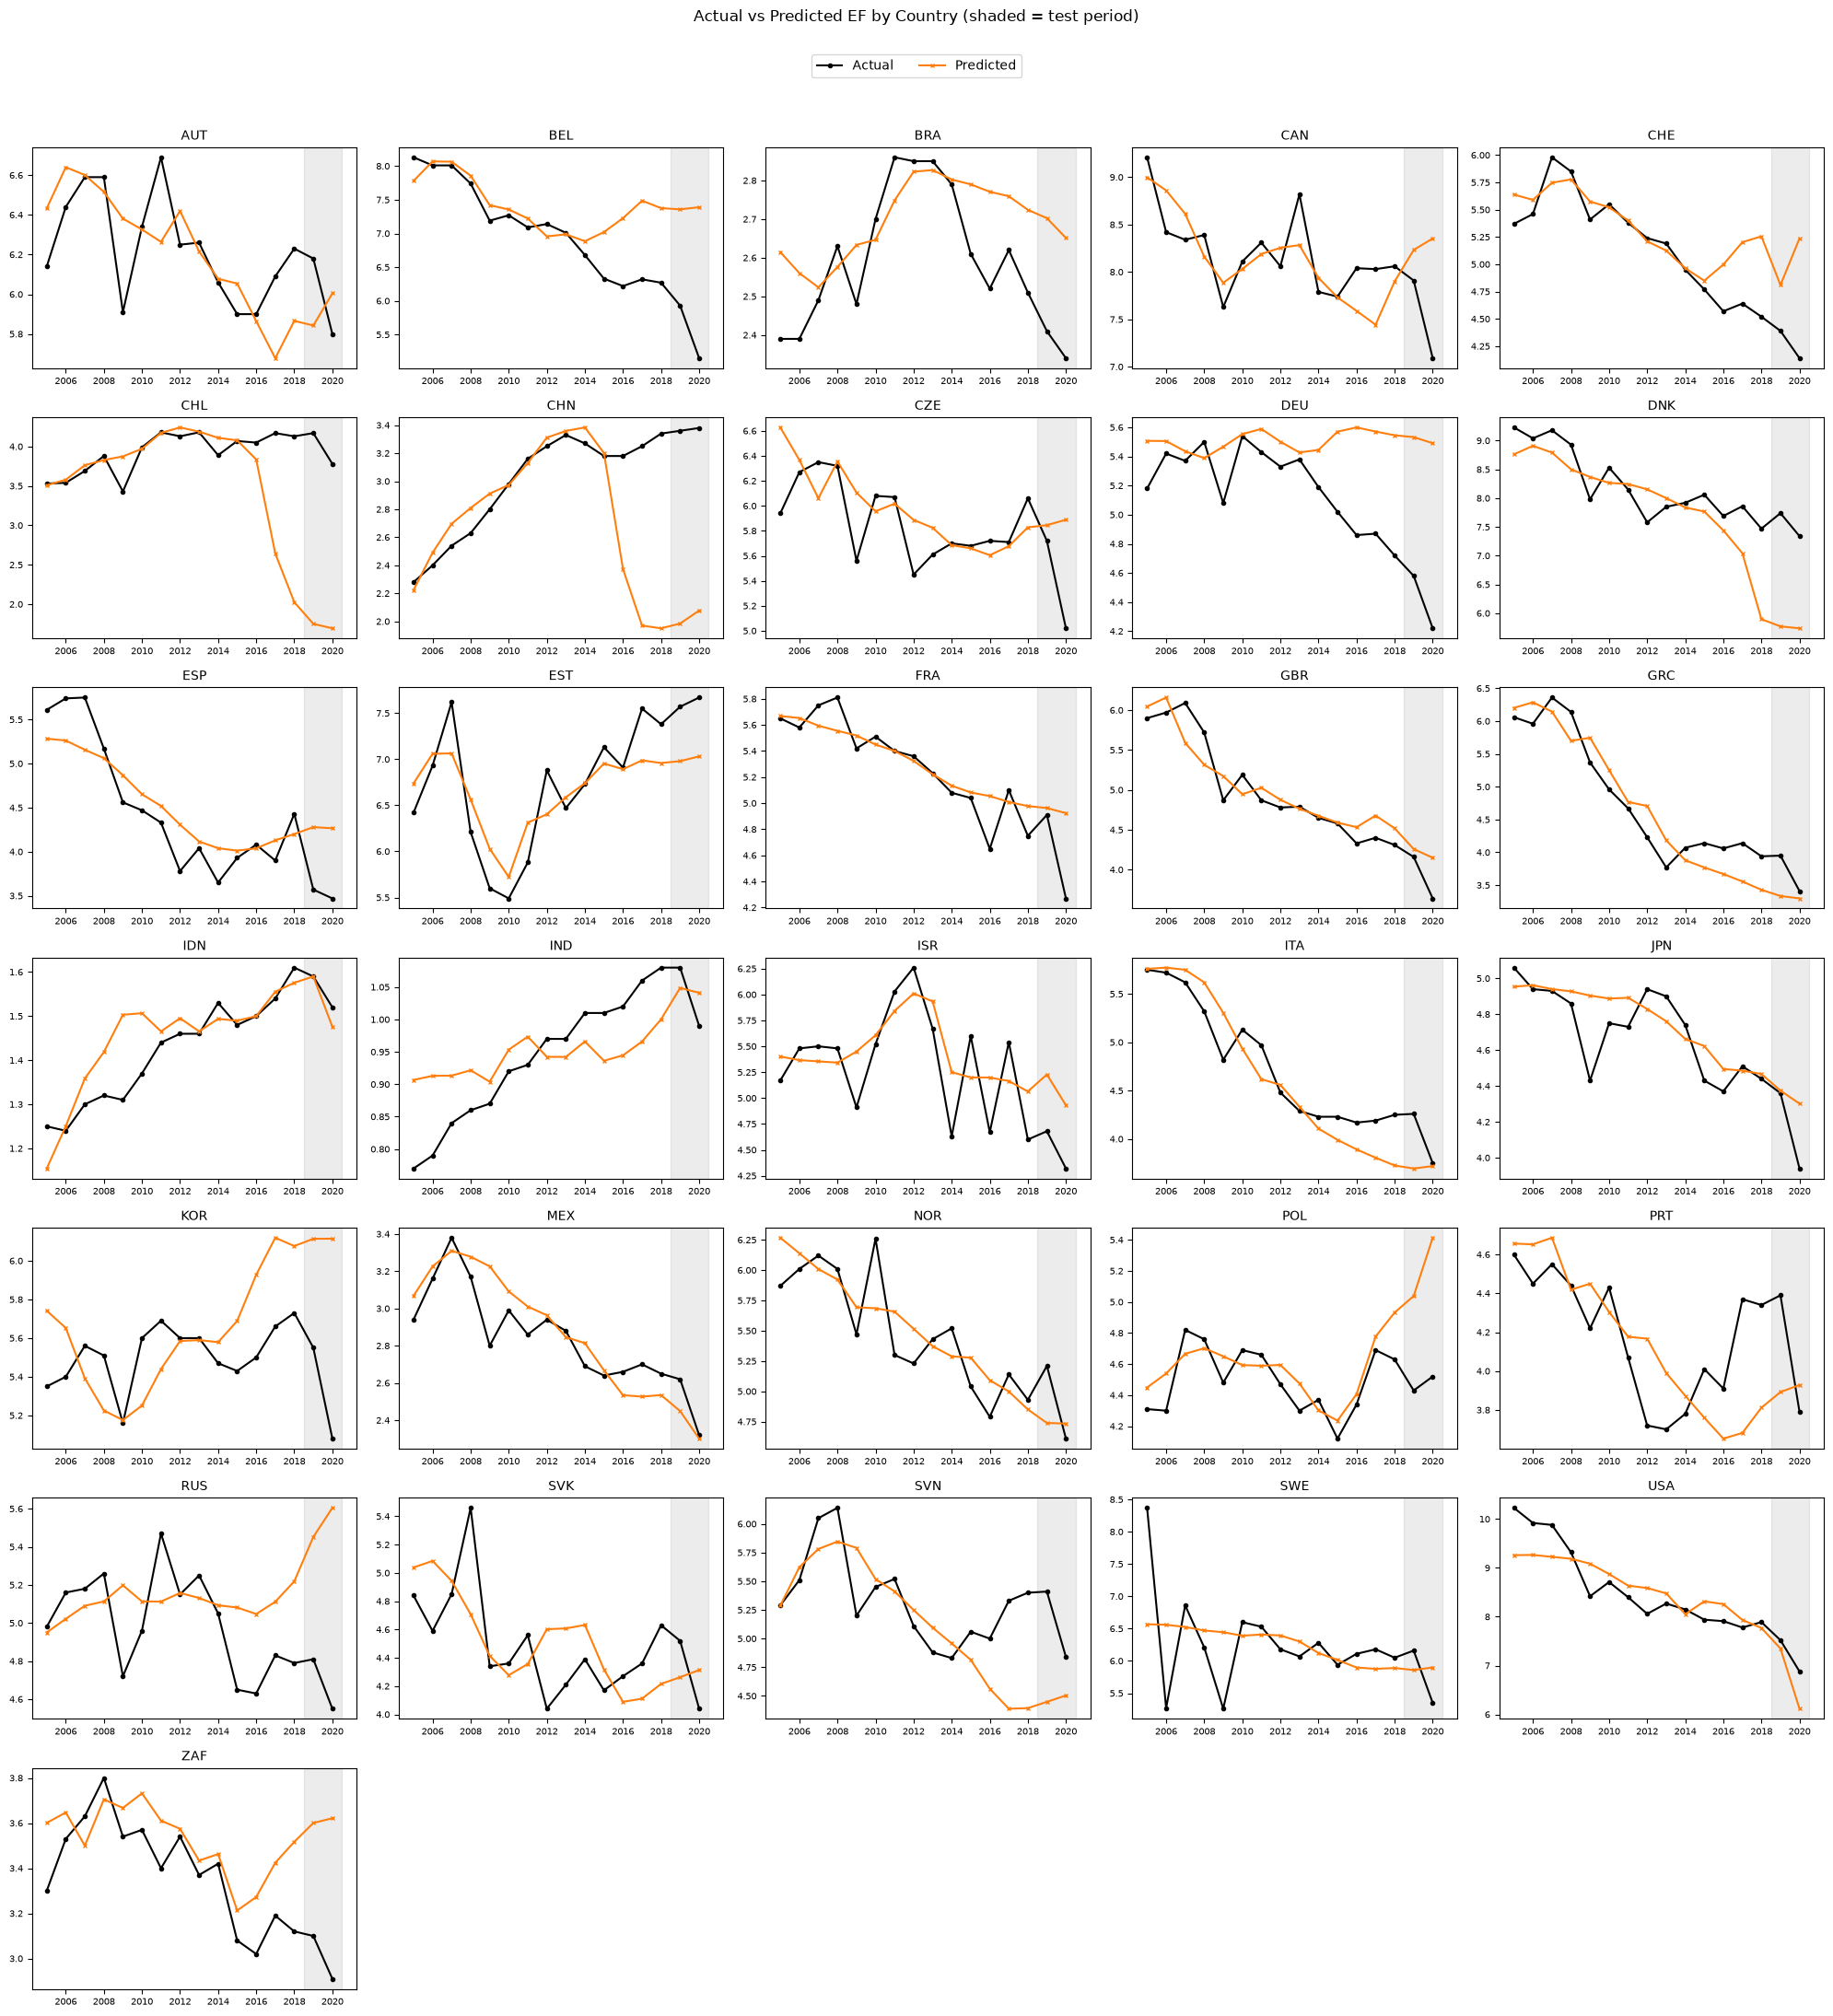

In [25]:
def get_predictions(X, meta):
    with torch.no_grad():
        preds = model(torch.tensor(X, dtype=torch.float32)).numpy()
    out = pd.DataFrame(meta, columns=["iso3", "year"])
    out["predicted"] = preds
    return out

train_preds = get_predictions(data["X_train"], data["meta_train"])
train_preds["actual"] = data["y_train"]; train_preds["split"] = "train"

val_preds = get_predictions(data["X_val"], data["meta_val"])
val_preds["actual"] = data["y_val"]; val_preds["split"] = "val"

test_preds = get_predictions(data["X_test"], data["meta_test"])
test_preds["actual"] = data["y_test"]; test_preds["split"] = "test"

all_preds = pd.concat([train_preds, val_preds, test_preds], ignore_index=True)
all_preds = all_preds.sort_values(["iso3", "year"])

countries = sorted(all_preds["iso3"].unique())
n = len(countries)
ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
axes = axes.flatten()

for i, country in enumerate(countries):
    ax = axes[i]
    sub = all_preds[all_preds["iso3"] == country]
    ax.plot(sub["year"], sub["actual"], marker='o', markersize=3, label="Actual", color="black")
    ax.plot(sub["year"], sub["predicted"], marker='x', markersize=3, label="Predicted", color="tab:orange")

    test_sub = sub[sub["split"] == "test"]
    if len(test_sub):
        ax.axvspan(test_sub["year"].min() - 0.5, test_sub["year"].max() + 0.5, color='gray', alpha=0.15)

    ax.set_title(country, fontsize=10)
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Actual vs Predicted EF by Country (shaded = test period)", y=1.04)
plt.tight_layout()
plt.show()